In [1]:
from matplotlib import pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
from pathlib import Path
import plotly.graph_objects as go
import seaborn as sns
import numpy as np

In [2]:
species_map = {
    "HS": "H. sapiens" ,
    "PT": "P. troglodytes",
    "RN":"R. norvegicus",
    "MM": "M. Musculus",
    "BT": "B. taurus",
    "OA":"O. aries",
    "XT":"X. tropicalis",
    "DR":"D. rerio",
    "DM":"D. melanogaster",
    "CE":"C. elegans",
    "SC":"S. cerevisiae",
    "AT":"A. thaliana",
}

### MS score: closed vs open search

In [3]:
def plot_compare_searches(df):
    df["group"] = df["mode"] + "_" + df["ms"]

    order = [
        "both_1+",
        "cs_1+",
        "dmo_1+",
        "cs_1",
        "dmo_1"
    ]

    plot_df = (
        df.pivot(index="species_sn", columns="group", values="n")
        .fillna(0)
        .reindex(columns=order, fill_value=0)
    )

    # Total per species
    totals = plot_df.sum(axis=1)

    # Sort species by total number of proteins
    plot_df = plot_df.loc[totals.sort_values(ascending=False).index]

    # Total per species before normalization
    totals = plot_df.sum(axis=1)

    # Normalize each species to 100%
    plot_df_pct = plot_df.div(plot_df.sum(axis=1), axis=0) * 100

    ax = plot_df_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(7, 4),
        color=["#292f56", "#1a5a86", "#00bfa6", "#12afcb", "#6bea8a"]
    )

    ax.set_xlabel("")
    ax.set_ylabel("AltProts (%)")
    ax.set_ylim(0, 110)

    plt.xticks(rotation=45, ha="right")

    # Add total above each bar
    for i, total in enumerate(totals):
        ax.text(i, 102, f"{total:,}", ha="center", va="bottom")
    ax.legend(
        handles=ax.get_legend_handles_labels()[0],
        labels=["Both", "Closed, MS>1", "Open, MS>1", "Closed, MS=1", "Open, MS=1"],
        title="Mode / MS",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )
    ax.set_xticks(range(len(plot_df)))

    ax.set_xticklabels(
        [species_map.get(x, x) for x in plot_df.index],
        rotation=45,
        ha="right"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    #formats = ["svg", "png"]
    #for format in formats:
    #    save_plot_path = os.path.join(save_plots_dir, f"altprots_compare_modes.{format}")
    #    plt.savefig(save_plot_path, format=format, bbox_inches = 'tight')

    plt.show()

    return plot_df, plot_df_pct

In [4]:
compmodes_sns = pd.read_csv("../input_data/compare_searches.csv")

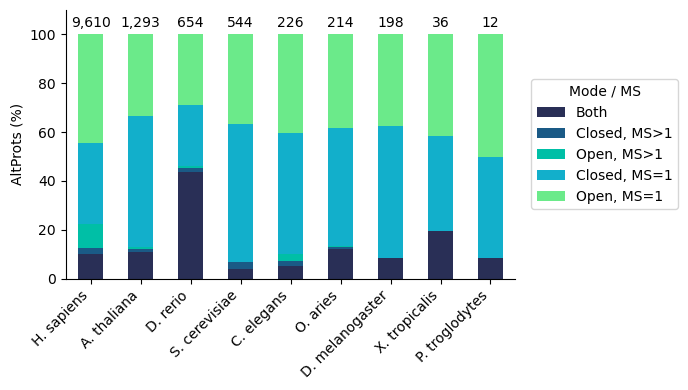

In [5]:
plot_df, plot_df_pct = plot_compare_searches(compmodes_sns)

### Modifications rate

In [6]:
def plot_prtmod(df, cap=7):
    df = df.copy()
    df["n_modified_sites"] = df["n_modified_sites"].clip(upper=cap)

    df_counts = (
        df[["n_peptides", "n_modified_sites"]]
        .value_counts()
        .reset_index(name="count")
    )

    xmin = df_counts["n_modified_sites"].min()
    xmax = df_counts["n_modified_sites"].max()

    n_categories = df_counts["n_peptides"].nunique()

    ax = sns.histplot(
        data=df_counts,
        x="n_modified_sites",
        weights="count",
        hue="n_peptides",
        multiple="stack",
        binwidth=1,
        binrange=(xmin - 0.5, xmax + 0.5),
        edgecolor="none",
        palette=sns.color_palette("Spectral_r", n_colors=n_categories)
    )
    sns.despine()
    ax.get_figure().set_size_inches(5,5)

    ticks = np.arange(xmin, xmax + 1)
    labels = [str(int(t)) for t in ticks]
    if xmax == cap:
        labels[-1] = f"{cap}+"
    plt.xticks(ticks, labels)

    plt.xlabel("Number of modified residues")
    plt.ylabel("Number of AltProts")

    ax.legend_.set_title("Number of\ndetected peptides")
    ax.legend_.set_bbox_to_anchor((0.7, 1))
    ax.legend_.set_loc("upper left")

    #formats = ["svg", "png"]
    #for format in formats:
    #    save_plot_path = os.path.join(save_plots_dir, f"hs_protmod.{format}")
    #    plt.savefig(save_plot_path, format=format, bbox_inches='tight')

    plt.show()

In [8]:
modsites_df = pd.read_csv(f"../input_data/mod_rate.csv")

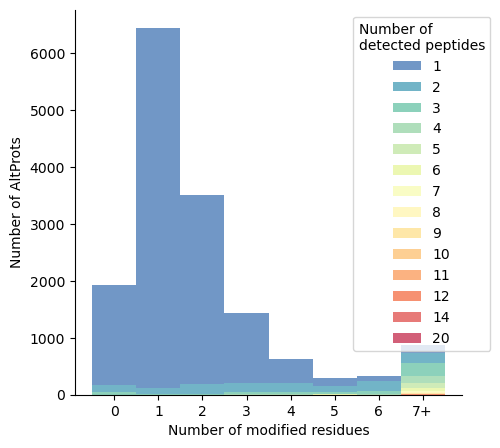

In [9]:
plot_prtmod(modsites_df)

### Top modifcations

In [10]:
def plot_modcounts(df_final, n):
    df_plot = df_final.head(n).copy()

    fig, ax = plt.subplots(figsize=(3, 5))
    df_plot["total_psm_count_log"] = np.log10(df_plot["total_psm_count"])
    sns.heatmap(
        df_plot.set_index("code")[["total_psm_count_log"]],
        cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True),
        ax=ax,
        cbar_kws={"label": f"log10(Total PSM count)"}
    )

    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_xticklabels([f"Top {n} AltProts modifications"])

    #formats = ["svg", "png"]
    #for format in formats:
    #    save_plot_path = os.path.join(save_plots_dir, f"hs_mod.{format}")
    #    plt.savefig(save_plot_path, format=format, bbox_inches = 'tight')

    plt.show()

In [11]:
modcounts_df = pd.read_csv("../input_data/mod_count.csv")

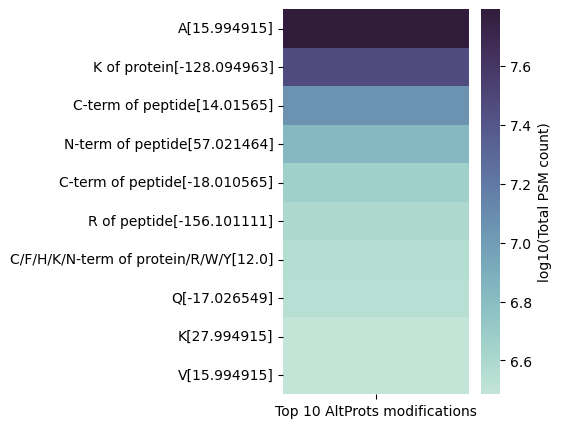

In [12]:
plot_modcounts(modcounts_df, n=10)